## 3. Logistic Regression

### 3.1 Packages importeren 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


from scipy import stats

from preprocessing import(
    spacy_preprocessor,
    spacy_tokenizer,
)
from helpfuncties import load_dataset

### 3.2 Dataset inladen 

In [3]:
df = load_dataset()
y = df['Product']
X = df['Omschrijving']

### 3.3 Train-Test Split

In [ ]:
# Hier wordt eenmalig een train/test split gedaan en  word er een train csv en test csv gemaakt die de andere modellen rechtstreeks kunnen gebruiken
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y # stratify op de product kolom, zorgt ervoor dat de verdeling van productsectoren in de train en test set gelijk blijft (omdat de product klassen ongelijk verdeeld zijn is dit belangrijk)
)

# Train dataframe maken 
train_df = pd.DataFrame({
    "Omschrijving": X_train,
    "Product": y_train
})

# test dataframe maken
test_df = pd.DataFrame({
    "Omschrijving": X_test,
    "Product": y_test
})

# train en test dataframes opslaan als csv bestanden 
train_df.to_csv("train.csv", index=True)
test_df.to_csv("test.csv", index=True)

### 3.4 Pipeline + Hyperparameter Tuning

#### 3.4.1 TF-IDF en Logistic Regression Pipeline

In [ ]:
tfidf = TfidfVectorizer( # TF-IDF vectorizer met de preprocesser en tokenizer van uit preprocessing.py 
        preprocessor=spacy_preprocessor,
        tokenizer=spacy_tokenizer,
        analyzer='word', # werkt op woord niveau (geen characters, geen zinnen) 
        ngram_range=(1,2), # unigrams en bigrams gebruiken. unigrams = 'credit', bigrams = 'credit card'. Verbetert de prestaties van het mmodel 
        token_pattern=None # None zodat de tokenizer uit preprocessing.py gebruikt wordt
    )

In [ ]:
model = LogisticRegression(max_iter=10000, class_weight='balanced', n_jobs=-1) # class_weight='balanced' zodat klassen met weinig data zwaarder meewegen tijdens het trainen (omdat de klassen ongelijk verdeeld zijn)

logreg_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('model', model)])   

#### 3.4.2 RandomizedSearchCV

In [7]:
random_params = {
    # Model Parameters 
    'model__C': stats.loguniform(1e-3, 200), # regularisatie sterkte. Kleine C = strenger model, grote C = flexibeler model. loguniform zodat kleine en grote waarden eerlijk worden gesampled 
    'model__class_weight': ['balanced', None], # test of het model beter werkt met of zonder correctie voor scheve klassen 
    'model__solver': ['lbfgs', 'saga'], # optimalisatie methode tuning 

    # TF-IDF Parameters 
    'tfidf__min_df': [1, 2, 3, 4, 5], # minimmale document freq (woorden die minder dan dit aantal documenten voorkomen worden weggegooid)
    'tfidf__max_df': [0.75, 0.8, 0.9, 1.0], # maximale document freq 
    'tfidf__ngram_range': [(1,1), (1,2), (1,3)], # test unigrams, bigrams of trigrams 
    'tfidf__max_features': [30000, 50000, None], # max features 
    'tfidf__sublinear_tf': [True, False], # log scaling 
    'tfidf__norm': ['l2', None], # normalisatie van tf idf 
    'tfidf__binary': [False, True], # test of alleen aanwezigheid van woorden telt (True) of ook frequentie (False).
    'tfidf__use_idf': [True, False] # IDF aan of uit 
} 

random_search = RandomizedSearchCV(
    logreg_pipeline,
    param_distributions=random_params,
    n_iter=80,
    scoring='precision_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best = random_search.best_params_

Fitting 3 folds for each of 80 candidates, totalling 240 fits


#### 3.4.3 GridSearchCV

In [ ]:
# GridSearch om de beste instellingen uit Random Search verder af te stellen 
grid_params = {
    # Model Parameters 
    'model__C': [
        best['model__C'] * 0.5,
        best['model__C'],
        best['model__C'] * 2
    ],
    'model__class_weight': [best['model__class_weight']],
    'model__solver': [best['model__solver']],
    
    # TF IDF Parameters 
    'tfidf__min_df': [
        max(1, best['tfidf__min_df'] - 1),
        best['tfidf__min_df'],
        best['tfidf__min_df'] + 1
    ],
    'tfidf__max_df': [best['tfidf__max_df']],
    'tfidf__ngram_range': [best['tfidf__ngram_range']],
    'tfidf__max_features': [best['tfidf__max_features']],
    'tfidf__sublinear_tf': [best['tfidf__sublinear_tf']],
    'tfidf__norm': [best['tfidf__norm']],
    'tfidf__binary': [best['tfidf__binary']],
    'tfidf__use_idf': [best['tfidf__use_idf']]
}

In [9]:
grid = GridSearchCV(
    logreg_pipeline,
    param_grid=grid_params,
    scoring='precision_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
logreg_pipeline = grid.best_estimator_

print("\nBeste Parameters GridSearch: ")
print(grid.best_params_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Beste Parameters GridSearch: 
{'model__C': np.float64(1.2844689156951186), 'model__class_weight': None, 'model__solver': 'lbfgs', 'tfidf__binary': True, 'tfidf__max_df': 0.8, 'tfidf__max_features': 30000, 'tfidf__min_df': 6, 'tfidf__ngram_range': (1, 3), 'tfidf__norm': 'l2', 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}


### 3.5 Evaluatie Modelprestaties 

#### 3.5.1 Voorspellingen

In [10]:
y_pred = logreg_pipeline.predict(X_test)
y_proba = logreg_pipeline.predict_proba(X_test)

#### 3.5.2 Classification report

In [11]:
print("\nClassification Report Logistic Regression:\n")
print(classification_report(y_test, y_pred))


Classification Report Logistic Regression:

                    precision    recall  f1-score   support

      Bankrekening       0.87      0.83      0.85       446
Consumentenkrediet       0.80      0.48      0.60       284
        Creditcard       0.82      0.80      0.81       564
         Hypotheek       0.89      0.95      0.92       994
           Incasso       0.82      0.88      0.85      1223
Kredietregistratie       0.82      0.82      0.82       934

          accuracy                           0.84      4445
         macro avg       0.84      0.79      0.81      4445
      weighted avg       0.84      0.84      0.84      4445



#### 3.5.3 Confusion Matrix

[[ 369    2   33   19   14    9]
 [   7  137   18   35   55   32]
 [  19    4  452    7   44   38]
 [  15    3    3  943   11   19]
 [   9   12   22   35 1072   73]
 [   3   13   26   20  105  767]]


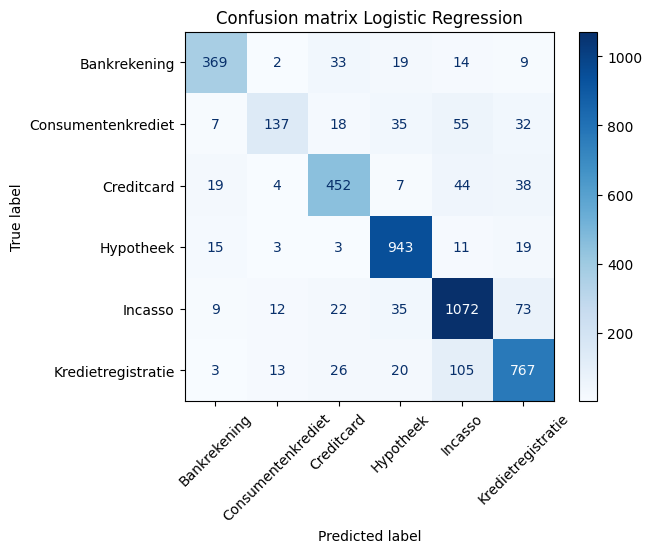

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.xticks(rotation=45)
plt.title('Confusion matrix Logistic Regression')
plt.savefig("afbeeldingen/confusion_matrix_logreg.png", dpi=300, bbox_inches='tight') 
plt.show()

### 3.5.4 Conclusie modelprestatie 

Het model haalt een weighted precision van 0,84. Geen van de productsectoren haalt de minimale eis van 90% precision per subklasse. De precision per klasse ligt tussen 0,80 en 0,89, waarbij Consumentenkrediet het laagst scoort. Dit is wel een goed baseline model. 